# Home Credit Default Risk Prediction

The bank is deciding whether to approve or reject a loan application.

In credit risk "Default" = the borrower fails to repay the loan as agreed.

There are four possible outcomes:
1. The bank approves the loan and the preson repays: bank earns interest and fees which means profit
2. The bank approves the loan and the person defaults: bank loses part of principal, legal costs, operational costs which means loss
3. The bank rejects the loan for someone who would repay: bank loses potential interest income and opportunity which means loss
4. The bank rejects the loan for someone who would default: bank avoids loss

Our goal: Estimate probability of default well enough to make profitable approval decisions

Decision rule: The loan should be approved if PD (probability of default) < p (derived from expected profit)

Evaluation metrics: expected profit, ROC-AUC (for ranking), Calibration (Brier score)

Expected profit is caluclated using this formula:
(1 - PD) * Revenue - PD * Loss

Using the following parameters:
1. Interest rate (r) = 18%
2. LGD = 60%
3. Loan amount = 30% of annual income

The threshold p becomes: 23%

In [59]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [2]:
path = 'Data/application_train.csv'

df = pd.read_csv(path, low_memory=False)
print(df.shape)
df.head()

(307511, 122)


,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0


In [3]:
df.memory_usage(deep=True).sum() / 1024**2

np.float64(504.98532581329346)

In [6]:
df.columns

Index(['SK_ID_CURR', 'TARGET', 'NAME_CONTRACT_TYPE', 'CODE_GENDER',
       'FLAG_OWN_CAR', 'FLAG_OWN_REALTY', 'CNT_CHILDREN', 'AMT_INCOME_TOTAL',
       'AMT_CREDIT', 'AMT_ANNUITY',
       ...
       'FLAG_DOCUMENT_18', 'FLAG_DOCUMENT_19', 'FLAG_DOCUMENT_20',
       'FLAG_DOCUMENT_21', 'AMT_REQ_CREDIT_BUREAU_HOUR',
       'AMT_REQ_CREDIT_BUREAU_DAY', 'AMT_REQ_CREDIT_BUREAU_WEEK',
       'AMT_REQ_CREDIT_BUREAU_MON', 'AMT_REQ_CREDIT_BUREAU_QRT',
       'AMT_REQ_CREDIT_BUREAU_YEAR'],
      dtype='object', length=122)

In [7]:
target = "TARGET"
df[target].value_counts(normalize=True)

TARGET
0    0.919271
1    0.080729
Name: proportion, dtype: float64

Data Leakage check

In [10]:
suspects = [c for c in df.columns if any(k in c.upper() for k in ["OVERDUE","DEFAULT","RECOVER","PAST","DUE"])]
suspects[:30], len(suspects)

([], 0)

Data quality check

Types and missing values

In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 307511 entries, 0 to 307510
Columns: 122 entries, SK_ID_CURR to AMT_REQ_CREDIT_BUREAU_YEAR
dtypes: float64(65), int64(41), object(16)
memory usage: 286.2+ MB


1. float64 - 65 columns
2. int64 - 41 columns
3. object - 16 columns

In [16]:
missing = df.isna().mean().sort_values(ascending=False)
missing.head(20)

COMMONAREA_AVG              0.698723
COMMONAREA_MODE             0.698723
COMMONAREA_MEDI             0.698723
NONLIVINGAPARTMENTS_MEDI    0.694330
NONLIVINGAPARTMENTS_MODE    0.694330
NONLIVINGAPARTMENTS_AVG     0.694330
FONDKAPREMONT_MODE          0.683862
LIVINGAPARTMENTS_AVG        0.683550
LIVINGAPARTMENTS_MEDI       0.683550
LIVINGAPARTMENTS_MODE       0.683550
FLOORSMIN_MODE              0.678486
FLOORSMIN_AVG               0.678486
FLOORSMIN_MEDI              0.678486
YEARS_BUILD_AVG             0.664978
YEARS_BUILD_MODE            0.664978
YEARS_BUILD_MEDI            0.664978
OWN_CAR_AGE                 0.659908
LANDAREA_MEDI               0.593767
LANDAREA_AVG                0.593767
LANDAREA_MODE               0.593767
dtype: float64

In [19]:
too_missing = missing[missing>0.6].index.tolist()
len(too_missing)

17

17 columns with too many missing values

In [23]:
cat_cols = df.select_dtypes(include=['object']).columns
card = df[cat_cols].nunique().sort_values(ascending=False)
card.head(20)

ORGANIZATION_TYPE             58
OCCUPATION_TYPE               18
NAME_INCOME_TYPE               8
NAME_TYPE_SUITE                7
WALLSMATERIAL_MODE             7
WEEKDAY_APPR_PROCESS_START     7
NAME_FAMILY_STATUS             6
NAME_HOUSING_TYPE              6
NAME_EDUCATION_TYPE            5
FONDKAPREMONT_MODE             4
HOUSETYPE_MODE                 3
CODE_GENDER                    3
FLAG_OWN_CAR                   2
NAME_CONTRACT_TYPE             2
FLAG_OWN_REALTY                2
EMERGENCYSTATE_MODE            2
dtype: int64

In [33]:
num_cols = df.select_dtypes(exclude=['object']).columns.drop(target)
df[num_cols].describe().T.sort_values('max', ascending=False).head(20)

,count,mean,std,min,25%,50%,75%,max
AMT_INCOME_TOTAL,307511.0,168797.919297,237123.146279,25650.0,112500.0,147150.0,202500.0,117000000.0
AMT_GOODS_PRICE,307233.0,538396.207429,369446.460540,40500.0,238500.0,450000.0,679500.0,4050000.0
AMT_CREDIT,307511.0,599025.999706,402490.776996,45000.0,270000.0,513531.0,808650.0,4050000.0
SK_ID_CURR,307511.0,278180.518577,102790.175348,100002.0,189145.5,278202.0,367142.5,456255.0
DAYS_EMPLOYED,307511.0,63815.045904,141275.766519,-17912.0,-2760.0,-1213.0,-289.0,365243.0
AMT_ANNUITY,307499.0,27108.573909,14493.737315,1615.5,16524.0,24903.0,34596.0,258025.5
OBS_30_CNT_SOCIAL_CIRCLE,306490.0,1.422245,2.400989,0.0,0.0,0.0,2.0,348.0
OBS_60_CNT_SOCIAL_CIRCLE,306490.0,1.405292,2.379803,0.0,0.0,0.0,2.0,344.0
AMT_REQ_CREDIT_BUREAU_QRT,265992.0,0.265474,0.794056,0.0,0.0,0.0,0.0,261.0
OWN_CAR_AGE,104582.0,12.061091,11.944812,0.0,5.0,9.0,15.0,91.0


In [26]:
from sklearn.model_selection import train_test_split

train_df, test_df = train_test_split(df, test_size=0.2, stratify=df[target], random_state=23)

The column DAYS_EMPLOYED seems to contain unreal large values like 365243.

Since looking at the days do determine if they are real or not is hard we will create a new column with year employed

In [41]:
df1 = train_df.copy()
df1['years_employed'] = (df1['DAYS_EMPLOYED']/365).astype(int)

We set a threshold for normal number of years employed which I will set to 80

In [42]:
threshold = 80
df1[df1['years_employed']>threshold]['years_employed'].unique()

array([1000])

In [43]:
df1_by_years_employed = df1['years_employed'].value_counts(normalize=True).reset_index()

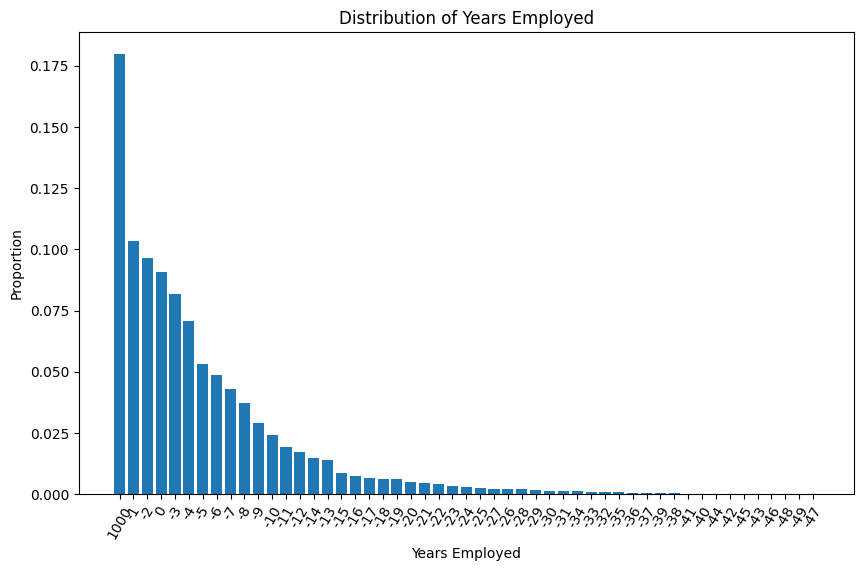

In [50]:
y = df1_by_years_employed['proportion']
x = df1_by_years_employed['years_employed'].astype(str)

fig, ax = plt.subplots(figsize=(10,6))
ax.bar(x,y)
ax.set_xlabel('Years Employed')
ax.set_ylabel('Proportion')
ax.set_title('Distribution of Years Employed')
plt.xticks(rotation=60)
plt.show()

In [51]:
df1[df1['years_employed']>threshold]['years_employed'].count()

np.int64(44216)

365243 is a sentinel value

Create anomaly flag

In [56]:
train_df['EMPLOYED_ANOMALY'] = (train_df['DAYS_EMPLOYED']==365243).astype(int)

In [60]:
train_df.loc[train_df['DAYS_EMPLOYED'] == 365243, 'DAYS_EMPLOYED'] = np.nan

In [71]:
pd.crosstab(train_df['EMPLOYED_ANOMALY'], train_df[target], normalize='index')

TARGET,0,1
EMPLOYED_ANOMALY,,
0,0.913322,0.086678
1,0.946422,0.053578


Seems like people with the employed anomaly default less

In [72]:
train_df['YEARS_EMPLOYED'] = -train_df['DAYS_EMPLOYED']/365

In [78]:
df1 = train_df.copy()
bins = [0,3,5,10,15,20,25,30,35,40,45,50]
labels = ["0-3","3-5","5-10","10-15","15-20","20-25","25-30","30-35","35-40","40-45","45-50"]
df1['binned_years_employed'] = pd.cut(df1['YEARS_EMPLOYED'],bins=bins,labels=labels)
df1_binned_years = pd.crosstab(df1['binned_years_employed'],df1[target],normalize='index').reset_index()
df1_binned_years

TARGET,binned_years_employed,0,1
0,0-3,0.890026,0.109974
1,3-5,0.902777,0.097223
2,5-10,0.926297,0.073703
3,10-15,0.940496,0.059504
4,15-20,0.952458,0.047542
5,20-25,0.951568,0.048432
6,25-30,0.961194,0.038806
7,30-35,0.963273,0.036727
8,35-40,0.980122,0.019878
9,40-45,0.993750,0.006250


Yes people who are employed longer default less, with the only exception beeing in the ages between 15-20 and 20-25, it seems that people who worked between 15-20 years default less than people who worked between 20-25.

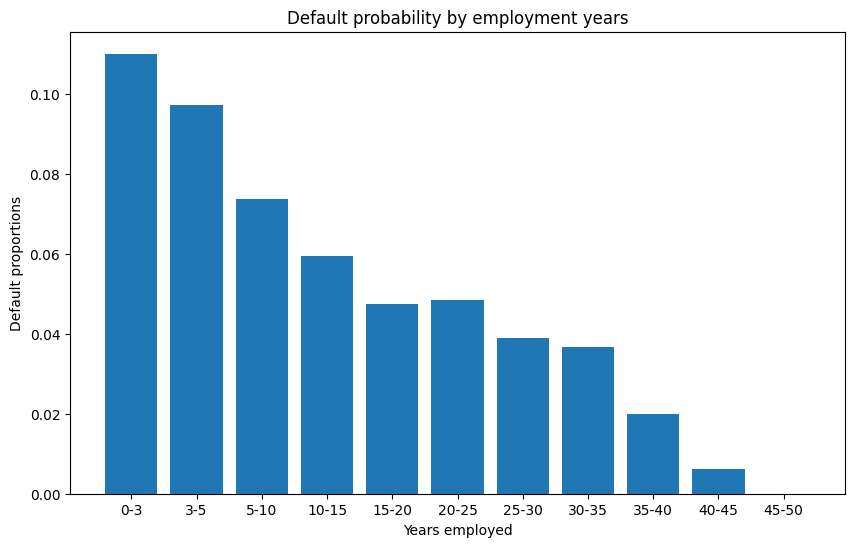

In [79]:
x = df1_binned_years['binned_years_employed']
y = df1_binned_years[1]

fig, ax = plt.subplots(figsize=(10,6))
ax.bar(x,y)
ax.set_xlabel('Years employed')
ax.set_ylabel('Default proportions')
ax.set_title('Default probability by employment years')
plt.show()

In [80]:
df1['YEARS_EMPLOYED'].max()

np.float64(49.07397260273972)

In [81]:
train_df['CREDIT_TO_INCOME'] = train_df['AMT_CREDIT'] / train_df['AMT_INCOME_TOTAL']
train_df['ANNUITY_TO_INCOME'] = train_df['AMT_ANNUITY'] / train_df['AMT_INCOME_TOTAL']

In [133]:
df1 = train_df.copy()

In [134]:
df1 = df1[['AMT_INCOME_TOTAL','AMT_CREDIT','AMT_ANNUITY','CREDIT_TO_INCOME','ANNUITY_TO_INCOME','YEARS_EMPLOYED','EMPLOYED_ANOMALY','TARGET']]

In [135]:
df1.isna().sum()

AMT_INCOME_TOTAL         0
AMT_CREDIT               0
AMT_ANNUITY              9
CREDIT_TO_INCOME         0
ANNUITY_TO_INCOME        9
YEARS_EMPLOYED       44216
EMPLOYED_ANOMALY         0
TARGET                   0
dtype: int64

In [136]:
df1['binned_credit_income_ratio'] = pd.qcut(df1['CREDIT_TO_INCOME'], q=10)
df1['binned_annuity_income_ratio'] = pd.qcut(df1['ANNUITY_TO_INCOME'], q=10)

In [137]:
df1.describe()

,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,CREDIT_TO_INCOME,ANNUITY_TO_INCOME,YEARS_EMPLOYED,EMPLOYED_ANOMALY,TARGET
count,2.460080e+05,2.460080e+05,245999.000000,246008.000000,245999.000000,201792.000000,246008.000000,246008.000000
mean,1.689096e+05,5.986312e+05,27094.128438,3.955604,0.180836,6.526230,0.179734,0.080729
std,2.589069e+05,4.019941e+05,14481.751785,2.691951,0.094676,6.400935,0.383967,0.272419
min,2.565000e+04,4.500000e+04,1615.500000,0.004808,0.000224,-0.000000,0.000000,0.000000
25%,1.125000e+05,2.700000e+05,16506.000000,2.018667,0.114543,2.104110,0.000000,0.000000
50%,1.467000e+05,5.135310e+05,24898.500000,3.259180,0.162618,4.509589,0.000000,0.000000
75%,2.025000e+05,8.086500e+05,34596.000000,5.156138,0.228945,8.693151,0.000000,0.000000
max,1.170000e+08,4.050000e+06,230161.500000,84.736842,1.875965,49.073973,1.000000,1.000000


In [138]:
df1_credit_income_default = pd.crosstab(df1['binned_credit_income_ratio'], df1['TARGET'], normalize='index').reset_index()
df1_annuity_income_default = pd.crosstab(df1['binned_annuity_income_ratio'], df1['TARGET'], normalize='index').reset_index()

In [139]:
df1_credit_income_default

TARGET,binned_credit_income_ratio,0,1
0,"(0.00381, 1.329]",0.932279,0.067721
1,"(1.329, 1.818]",0.923002,0.076998
2,"(1.818, 2.264]",0.919496,0.080504
3,"(2.264, 2.764]",0.907673,0.092327
4,"(2.764, 3.259]",0.913120,0.086880
5,"(3.259, 3.903]",0.906639,0.093361
6,"(3.903, 4.722]",0.913699,0.086301
7,"(4.722, 5.771]",0.921626,0.078374
8,"(5.771, 7.486]",0.925875,0.074125
9,"(7.486, 84.737]",0.929295,0.070705


In [142]:
df1_annuity_income_default

TARGET,binned_annuity_income_ratio,0,1
0,"(-0.000776, 0.0799]",0.929352,0.070648
1,"(0.0799, 0.103]",0.926786,0.073214
2,"(0.103, 0.125]",0.922371,0.077629
3,"(0.125, 0.144]",0.921415,0.078585
4,"(0.144, 0.163]",0.920644,0.079356
5,"(0.163, 0.186]",0.916098,0.083902
6,"(0.186, 0.212]",0.914194,0.085806
7,"(0.212, 0.247]",0.912187,0.087813
8,"(0.247, 0.302]",0.910732,0.089268
9,"(0.302, 1.876]",0.918899,0.081101


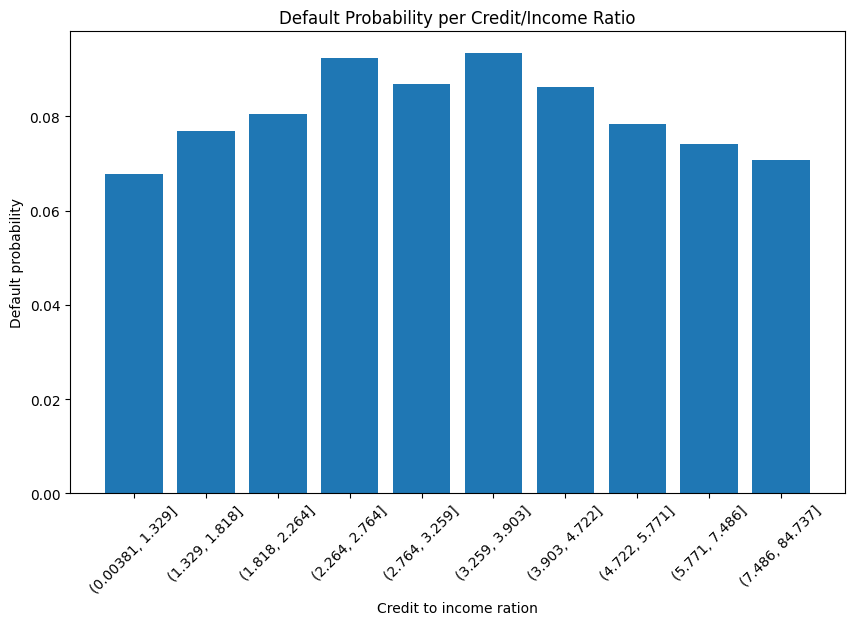

In [140]:
x = df1_credit_income_default['binned_credit_income_ratio'].astype(str)
y = df1_credit_income_default[1]

fig, ax = plt.subplots(figsize=(10,6))
ax.bar(x,y)
ax.set_xlabel('Credit to income ration')
ax.set_ylabel('Default probability')
ax.set_title('Default Probability per Credit/Income Ratio')
plt.xticks(rotation=45)
plt.show()

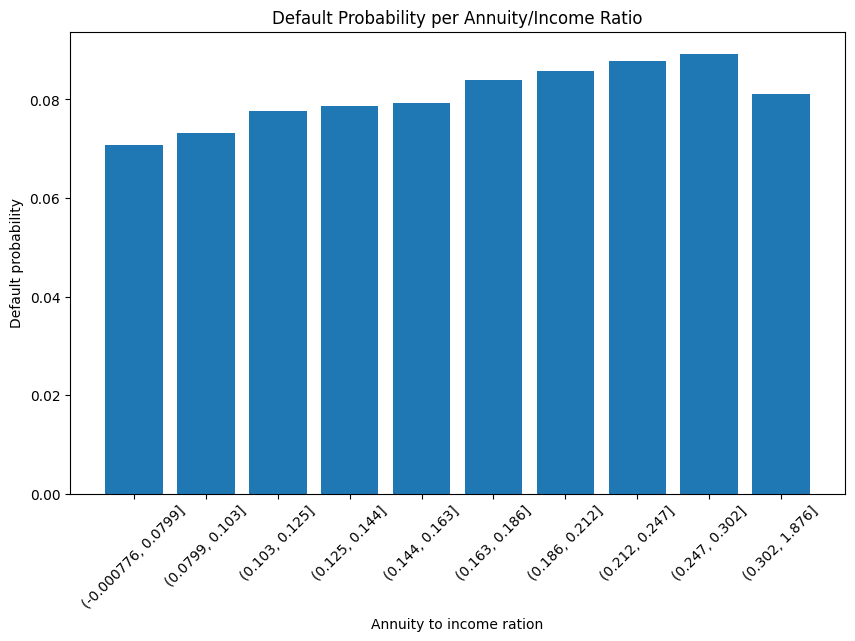

In [141]:
x = df1_annuity_income_default['binned_annuity_income_ratio'].astype(str)
y = df1_annuity_income_default[1]

fig, ax = plt.subplots(figsize=(10,6))
ax.bar(x,y)
ax.set_xlabel('Annuity to income ration')
ax.set_ylabel('Default probability')
ax.set_title('Default Probability per Annuity/Income Ratio')
plt.xticks(rotation=45)
plt.show()

In [145]:
df1.groupby('binned_annuity_income_ratio')[target].count()

/tmp/ipykernel_282260/947156242.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df1.groupby('binned_annuity_income_ratio')[target].count()


binned_annuity_income_ratio
(-0.000776, 0.0799]    24601
(0.0799, 0.103]        24599
(0.103, 0.125]         24617
(0.125, 0.144]         24585
(0.144, 0.163]         24598
(0.163, 0.186]         24600
(0.186, 0.212]         24602
(0.212, 0.247]         24609
(0.247, 0.302]         24589
(0.302, 1.876]         24599
Name: TARGET, dtype: int64

In [149]:
df1['ANNUITY_TO_INCOME'].min()

np.float64(0.00022388461538461538)